In [24]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from joblib import Parallel, delayed
from datatools import *
import matplotlib.pyplot as plt
import seaborn as sns

### 策略

In [ ]:
all_sample = pd.read_parquet('C:/Users/User/OneDrive - CUHK-Shenzhen/data/factor/all_sample.parquet')

In [2]:
start_date = '2019-01-01'
end_date = '2026-04-30'
allstocks = pd.read_csv('C:/Users/User/OneDrive - CUHK-Shenzhen/data/allstock.csv')
allstocks = allstocks[~allstocks['ts_code'].str.contains('BJ')].ts_code.tolist()
load_start = (pd.Timestamp(start_date) - pd.DateOffset(years=1)).strftime('%Y-%m-%d')
price = get_price(codes=allstocks, start_date=load_start, end_date=end_date).rename(columns={'open':'next_open'})
price = price.sort_values(by=['ts_code', 'trade_date']).reset_index(drop=True)
price['next_open'] = price.groupby('ts_code')['next_open'].shift(-1)

### rsrs

In [ ]:
# ── 构建矩阵 ──────────────────────────────────────────────────────────────
dates = np.sort(price['trade_date'].unique())
universe = np.sort(price['ts_code'].unique())

high_pivot = price.pivot(index='trade_date', columns='ts_code', values='high').reindex(index=dates, columns=universe)
low_pivot = price.pivot(index='trade_date', columns='ts_code', values='low').reindex(index=dates, columns=universe)

n_dates, n_stocks = len(dates), len(universe)
print(f'矩阵: {n_dates} 交易日 × {n_stocks} 只股票')
N=18
M=600
cov_xy = high_pivot.rolling(N, min_periods=2).cov(low_pivot)
var_x = low_pivot.rolling(N, min_periods=2).var()
var_y = high_pivot.rolling(N, min_periods=2).var()
slope = cov_xy / var_x
r2 = (cov_xy ** 2) / (var_x * var_y)
slope_zscore = (slope - slope.rolling(M, min_periods=2).mean()) / slope.rolling(M, min_periods=2).std()
rsrs = slope*r2*slope_zscore
rsrs = rsrs.loc[start_date:end_date]
rsrs = rsrs.stack().reset_index().rename(columns={0:'rsrs'})

矩阵: 4955 交易日 × 5489 只股票


### 最低点策略

In [ ]:
price['min_close'] = price.groupby('ts_code')['close'].rolling(window=185, min_periods=185).min().reset_index(level=0, drop=True)
price['signal'] = price['close'] == price['min_close']
price['sell_price'] = price.groupby('ts_code')['next_open'].shift(-38)
price['sell_date'] = price.groupby('ts_code')['trade_date'].shift(-38)
trade_records = price[(price['signal'] == 1)&(price['sell_price'].notna())]
trade_records['return_rate'] = (trade_records['sell_price'] - trade_records['next_open']) / trade_records['next_open']
trade_records = trade_records[['ts_code', 'trade_date', 'next_open', 'sell_date', 'sell_price', 'return_rate']]
trade_records['return_rate'] -= 0.003
win_trades = len(trade_records[trade_records['return_rate'] > 0])
avg_return = trade_records['return_rate'].mean()
total_return = trade_records['return_rate'].sum()
strategy_summary = {
    '总交易次数': len(trade_records),
    '盈利次数': win_trades,
    '胜率': f"{win_trades / len(trade_records):.2%}",
    '平均单次收益率': f"{avg_return:.2%}",
    '累计收益率(简单累加)': f"{total_return:.2%}"}

In [ ]:
# 1. 原有买入信号逻辑：close等于过去185个交易日的最低价
price['min_close'] = price.groupby('ts_code')['close'].rolling(window=185, min_periods=185).min().reset_index(level=0, drop=True)
price['buy_signal'] = price['close'] == price['min_close']
# 2. 新增卖出信号逻辑：close等于过去185个交易日的最高价
price['max_close'] = price.groupby('ts_code')['close'].rolling(window=185, min_periods=185).max().reset_index(level=0, drop=True)
price['sell_signal'] = price['close'] == price['max_close']
price['row_num'] = price.index
# 4. 寻找买入信号之后最近的一个卖出信号 记录卖出信号所在行的索引，非卖出信号行记为NaN
price['next_sell_idx'] = price.index.where(price['sell_signal'] == 1, np.nan)
# 按股票分组向后填充，使每一行都获取其之后第一个卖出信号的索引
price['next_sell_idx'] = price.groupby('ts_code')['next_sell_idx'].bfill()
# 5. 提取交易记录：当存在买入信号，且之后存在卖出机会时
trade_records = price[(price['buy_signal'] == 1) & (price['next_sell_idx'].notna())]
# 6. 构建卖出信号特征的映射字典
sell_price_map = price.loc[price['sell_signal'] == 1, 'next_open']
sell_date_map = price.loc[price['sell_signal'] == 1, 'trade_date']
sell_row_map = price.loc[price['sell_signal'] == 1, 'row_num']
# 7. 映射获取对应的卖出价、卖出日期和卖出行号
trade_records['sell_price'] = trade_records['next_sell_idx'].map(sell_price_map)
trade_records['sell_date'] = trade_records['next_sell_idx'].map(sell_date_map)
trade_records['sell_row_num'] = trade_records['next_sell_idx'].map(sell_row_map)
# 8. 新增持有周期列（交易日天数）并计算收益率
# 持有周期 = 卖出信号触发行号 - 买入信号触发行号
trade_records['hold_period'] = trade_records['sell_row_num'] - trade_records['row_num']
# 收益率 = (卖出价 - 买入价) / 买入价 （买入价使用信号日的next_open）
trade_records['return_rate'] = (trade_records['sell_price'] - trade_records['next_open']) / trade_records['next_open']
trade_records = trade_records[['ts_code', 'trade_date', 'next_open', 'sell_date', 'sell_price', 'return_rate','hold_period']]

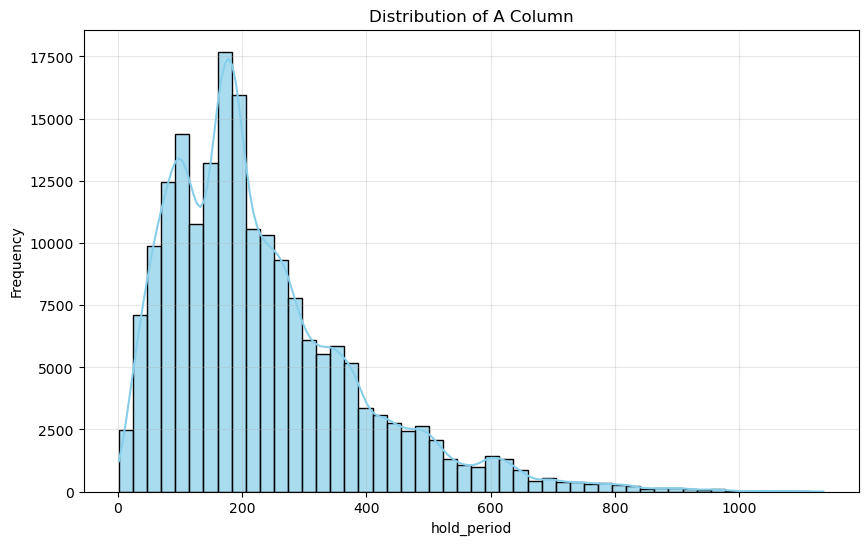

In [25]:
plt.figure(figsize=(10, 6))
sns.histplot(trade_records['hold_period'], kde=True, bins=50, color='skyblue', alpha=0.7)
plt.title('Distribution of A Column')
plt.xlabel('hold_period')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.show()

In [27]:
trade_records = trade_records.sort_values(by='sell_date').reset_index(drop=True)
trade_records['cum_value'] = (1 + trade_records['return_rate']).cumprod()

c:\Users\User\miniconda3\envs\mindigital\Lib\site-packages\numpy\_core\fromnumeric.py:57: RuntimeWarning: overflow encountered in accumulate
  return bound(*args, **kwds)


In [ ]:
# 1. 胜率：收益率为正的交易笔数占总交易笔数的比例
win_rate = (trade_records['return_rate'] > 0).mean()
# 2. 构建资金曲线：按卖出日期排序，计算累计净值
trade_records = trade_records.sort_values(by='sell_date').reset_index(drop=True)
# 假设每次交易投入相同资金，资金曲线按复利累计
trade_records['cum_value'] = (1 + trade_records['return_rate']).cumprod()
# 3. 最大回撤：资金曲线从最高点到随后最低点的最大下降幅度
cummax = trade_records['cum_value'].cummax()
drawdown = (trade_records['cum_value'] - cummax) / cummax
max_drawdown = drawdown.min()
# 4. 夏普比率：基于单次交易收益进行年化处理
mean_return = trade_records['return_rate'].mean()
std_return = trade_records['return_rate'].std()
# 计算平均持有周期（交易日）
avg_hold_period = trade_records['hold_period'].mean()
# 一年内发生的平均交易次数
annual_trade_freq = 252 / avg_hold_period if avg_hold_period > 0 else 1
# 年化收益率与年化标准差
annualized_return = mean_return * annual_trade_freq
annualized_std = std_return * np.sqrt(annual_trade_freq)
# 夏普比率 = (年化收益 - 无风险利率) / 年化标准差
sharpe_ratio = (annualized_return - 0.02 ) / annualized_std if annualized_std > 0 else 0
# 打印评估结果
print(f"总交易次数: {len(trade_records)}")
print(f"胜率: {win_rate:.2%}")
print(f"最大回撤: {max_drawdown:.2%}")
print(f"夏普比率: {sharpe_ratio:.4f}")

In [ ]:
trade_records['orig_idx'] = trade_records.index
trade_records['idx_diff'] = trade_records.groupby('ts_code')['orig_idx'].diff()
trade_records['block_id'] = trade_records['idx_diff'] != 1
trade_records['block_id'] = trade_records['block_id'].cumsum()
result = trade_records.groupby(['ts_code', 'block_id']).agg(trade_date=('trade_date', 'first'), 连续出现天数=('trade_date', 'count')).reset_index()
result.consecutive_days.value_counts(normalize=True).cumsum()

consecutive_days
1     0.461248
2     0.706244
3     0.831445
4     0.912933
5     0.951944
6     0.977194
7     0.990193
8     0.995643
9     0.997642
10    0.998634
11    0.999166
12    0.999497
13    0.999684
14    0.999784
15    0.999842
18    0.999885
19    0.999914
16    0.999942
20    0.999971
17    0.999986
22    1.000000
Name: proportion, dtype: float64

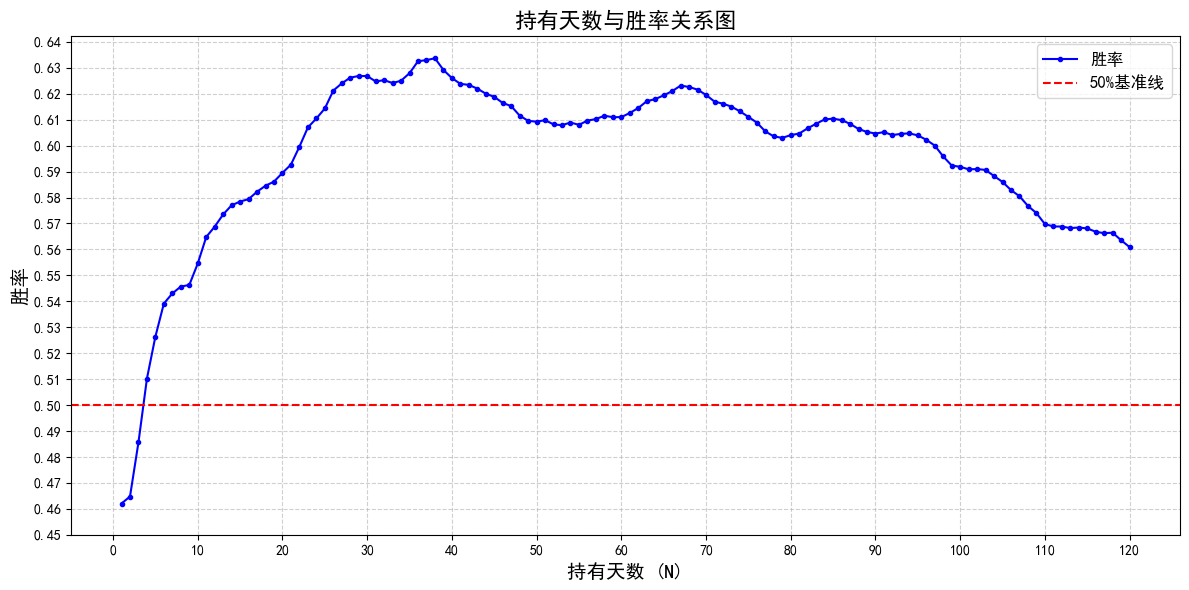

In [37]:
price['min_close'] = price.groupby('ts_code')['close'].rolling(window=185, min_periods=185).min().reset_index(level=0, drop=True)
price['signal'] = price['close'] == price['min_close']
holding_days_list = []
win_rates_list = []
# 3. 遍历 1 到 max_days 天，计算不同持有期下的胜率
for n in range(1, 120 + 1):
    price['sell_price'] = price.groupby('ts_code')['next_open'].shift(-n)
    price['sell_date'] = price.groupby('ts_code')['trade_date'].shift(-n)
    trade_records = price[(price['signal'] == 1)&(price['sell_price'].notna())]
    # 计算该笔交易是否盈利（卖出价 > 买入价）
    win_rate = (trade_records['sell_price']>trade_records['next_open']).sum() / len(trade_records)
    holding_days_list.append(n)
    win_rates_list.append(win_rate)
# 返回计算结果的数据框，便于查看具体数值
result_price = pd.DataFrame({'holding_days': holding_days_list, 'win_rate': win_rates_list})
# 4. 绘制折线图
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(12, 6))
plt.plot(holding_days_list, win_rates_list, marker='o', markersize=3, linestyle='-', color='b', label='胜率')
# 添加50%基准线，便于判断盈亏优势
plt.axhline(y=0.5, color='r', linestyle='--', label='50%基准线')
plt.title('持有天数与胜率关系图', fontsize=16)
plt.xlabel('持有天数 (N)', fontsize=14)
plt.ylabel('胜率', fontsize=14)
plt.xticks(np.arange(0, 120 + 1, 10))
plt.yticks(np.arange(0.45, 0.65, 0.01))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

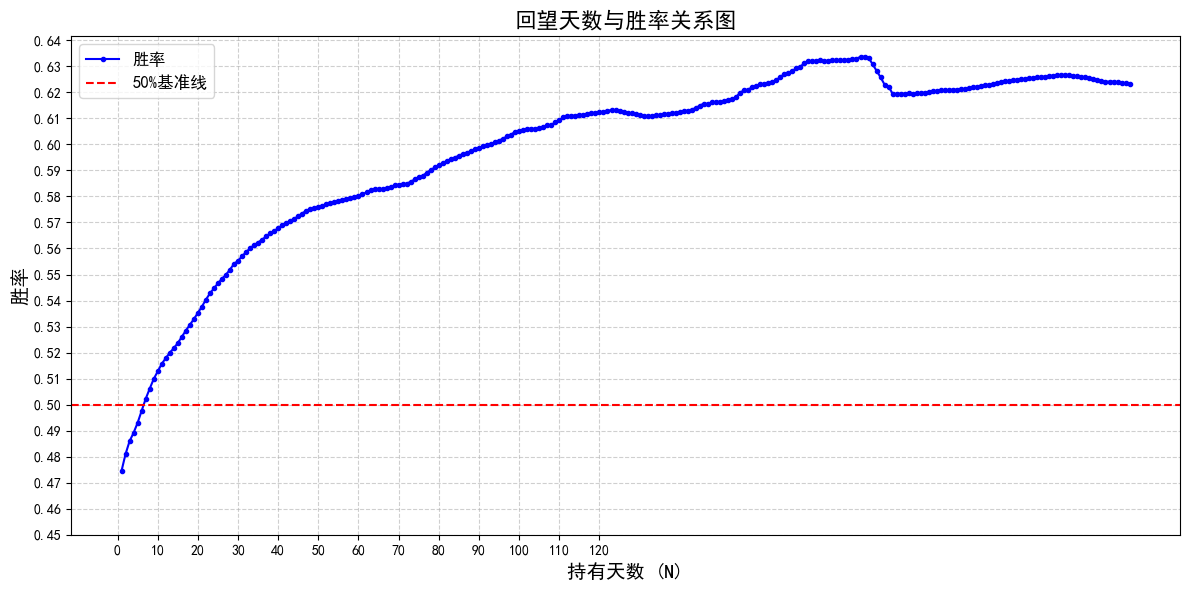

In [ ]:
price['sell_price'] = price.groupby('ts_code')['next_open'].shift(-38)
price['sell_date'] = price.groupby('ts_code')['trade_date'].shift(-38)
holding_days_list = []
win_rates_list = []
# 3. 遍历 1 到 max_days 天，计算不同持有期下的胜率
for n in range(1, 252 + 1):
    price['min_close'] = price.groupby('ts_code')['close'].rolling(window=n, min_periods=n).min().reset_index(level=0, drop=True)
    price['signal'] = price['close'] == price['min_close']
    trade_records = price[(price['signal'] == 1)&(price['sell_price'].notna())]
    # 计算该笔交易是否盈利（卖出价 > 买入价）
    win_rate = (trade_records['sell_price']>trade_records['next_open']).sum() / len(trade_records)
    holding_days_list.append(n)
    win_rates_list.append(win_rate)
# 返回计算结果的数据框，便于查看具体数值
result_price = pd.DataFrame({'holding_days': holding_days_list, 'win_rate': win_rates_list})